In [ ]:
import numpy as np

In [ ]:
from sklearn.datasets import fetch_openml

In [ ]:
mnist = fetch_openml('mnist_784', as_frame=False)

In [ ]:
type(mnist)

sklearn.utils._bunch.Bunch

In [ ]:
X, y = mnist.data, mnist.target

In [ ]:
X.shape, y.shape

((70000, 784), (70000,))

In [ ]:
np.sqrt(784)

np.float64(28.0)

In [ ]:
y[1]

'0'

In [ ]:
import matplotlib.pyplot as plt

def plot_digit(data):
  image = data.reshape(28, 28)
  plt.imshow(image, cmap='binary')
  plt.axis('off')

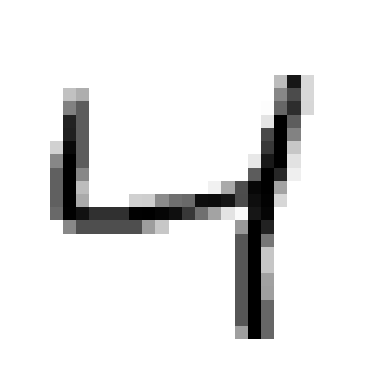

In [ ]:
plot_digit(X[2])

In [ ]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

Будем решать задачу мультиклассовой классификации

In [ ]:
from sklearn.svm import SVC

In [ ]:
svm_clf = SVC(random_state=2025)

In [ ]:
svm_clf.fit(X_train[:2000], y_train[:2000])

SVC(random_state=2025)

['5'] 5


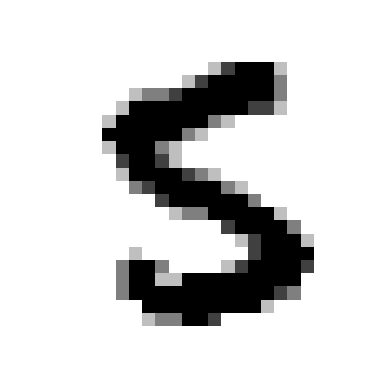

In [ ]:
digit_num = 132

plot_digit(X_test[digit_num])
print(svm_clf.predict([X_test[digit_num]]), y_test[digit_num])

In [ ]:
X_test[digit_num]

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0, 122, 194, 255, 254, 171, 101,   3,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,  13, 229, 253, 253, 253, 253, 253,
       126,   4,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,  29, 212, 200, 20

In [ ]:
from PIL import Image
img = Image.open('/content/my_digit_3.png')

In [ ]:
print(img.format)
print(img.size)
print(img.mode)

PNG
(28, 28)
RGB


In [ ]:
my_digit = 255 - np.array(img.convert('L'))

['2']


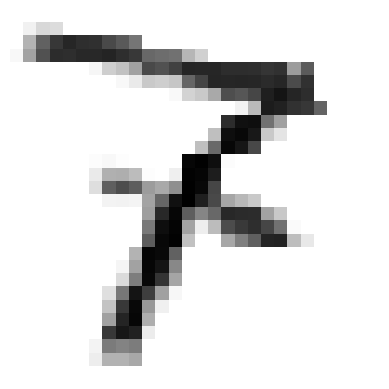

In [ ]:
plot_digit(my_digit)
print( svm_clf.predict([my_digit.flatten()]) )

In [ ]:
np.round(svm_clf.decision_function([my_digit.flatten()]), 2)

array([[-0.29,  2.8 ,  1.76,  6.2 ,  9.3 ,  3.83,  0.71,  7.27,  5.16,
         8.27]])

In [ ]:
from sklearn.linear_model import SGDClassifier

In [ ]:
sgd_clf = SGDClassifier(random_state=2025)

In [ ]:
sgd_clf.fit(X_train, y_train)

SGDClassifier(random_state=2025)

In [ ]:
print( sgd_clf.predict([my_digit.flatten()]) )

['3']


In [ ]:
from sklearn.model_selection import cross_val_score

In [ ]:
cross_val_score(svm_clf, X_train[:2000], y_train[:2000], cv=3, scoring="accuracy")

array([0.91754123, 0.89955022, 0.93693694])

In [ ]:
cross_val_score(sgd_clf, X_train[:2000], y_train[:2000], cv=3, scoring="accuracy")

array([0.84557721, 0.81109445, 0.84084084])